# Spatial Encoding in EEG: Channel Tuning Functions

Channel Tuning Functions (CTF) reveal how EEG channels encode spatial position. This tutorial analyzes spatial selectivity across frequency bands (broadband, alpha), power types (evoked vs total), and task contexts (localizer vs main task).

In [25]:
%matplotlib inline

import sys, os, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

warnings.filterwarnings('ignore')
sys.path.insert(0, '/Users/dvm/Documents/DvM')

from open_dvm.analysis import CTF
from open_dvm.support.FolderStructure import FolderStructure
from open_dvm.visualization.plot import plot_ctf_timecourse

print("✓ Imports successful")

✓ Imports successful


In [26]:
# Configuration
project_folder = '/Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM'
os.chdir(project_folder)
sj = 2

eye_dict = {
    'use_tracker': True, 'window_oi': (0, 0.3), 'angle_thresh': 1,
    'viewing_dist': 70, 'screen_res': (1920, 1080), 'screen_h': 29,
    'drift_correct': (-0.2, 0)
}

df, epochs = FolderStructure().load_processed_epochs(sj, 'ses_01_main', 'main', eye_dict)

print(f'✓ Subject {sj} loaded: {len(epochs)} trials, {epochs.info["nchan"]} channels')

Reading /Users/dvm/Library/CloudStorage/OneDrive-VrijeUniversiteitAmsterdam/projects/openDvM/eeg/processed/sub_02_ses_01_main-epo.fif ...
    Found the data of interest:
        t =    -699.22 ...    1000.00 ms
        0 CTF compensation matrices available
Adding metadata with 19 columns
2902 matching events found
No baseline correction applied
0 projection items activated
Eye channel is not specified in eyedict, using HEOG as default
4 trials missing eyetracking
data (used eog instead)
Eye exclusion info saved in preprocessing file (session 1)
✓ Subject 2 loaded: 2148 trials, 39 channels


## Broadband Spatial Tuning

In [27]:
# Initialize and compute broadband CTF
ctf_localizer = CTF(
    sj=sj, epochs=epochs, df=df, to_decode='img_loc',
    nr_bins=8, nr_chans=8, elec_oi='all', filter=8,
    avg_ch=True, baseline=(-0.2, 0), downsample=128
)

ctfs, ctf_params, _ = ctf_localizer.spatial_ctf(
    pos_labels='all', cnds=dict(block_type=['localizer']),
    window_oi=(-0.2, 0.5), freqs='broadband'
)

print("✓ Broadband CTF computed")

Creating bassiset with sin_power  7
Setting up low-pass filter at 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 845 samples (1.650 s)

Frequency 1 out of 1
Applying baseline correction (mode: mean)
Running ctf for localizer condition
get ctf tuning params
✓ Broadband CTF computed


Times converted from seconds to milliseconds
not enough colors specified. Using default colors
Times converted from seconds to milliseconds
Using a threshold of nan
stat_fun(H1): min=nan max=nan
Running initial clustering …
Found 0 clusters


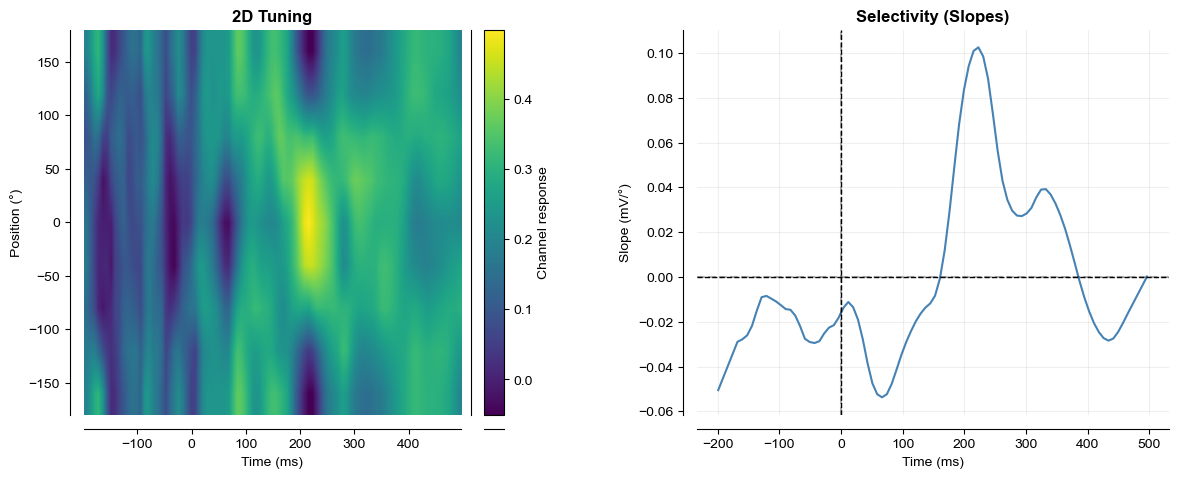

✓ Broadband visualization complete


In [28]:
# Visualize broadband
fig = plt.figure(figsize=(14, 5))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.3)

ax1 = fig.add_subplot(gs[0, 0])
plt.sca(ax1)
plot_ctf_timecourse(ctfs, cnds=['localizer'], timecourse='2d_ctf',
                    output='C2_voltage', stats=None, smooth=True)
ax1.set_title('2D Tuning', fontsize=12, fontweight='bold')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Position (°)')

ax2 = fig.add_subplot(gs[0, 1])
plt.sca(ax2)
plot_ctf_timecourse(ctf_params, cnds=['localizer'], colors=['steelblue'],
                    output='voltage_slopes', smooth=True, show_legend=False)
ax2.set_title('Selectivity (Slopes)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time (ms)')
ax2.set_ylabel('Slope (mV/°)')
ax2.axhline(0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.2)

plt.tight_layout()
display(fig)
plt.close('all')

print("✓ Broadband visualization complete")

## Alpha-Band Spatial Tuning (Evoked vs Total Power)

In [29]:
# Compute alpha-band CTF
ctfs_alpha, ctf_params_alpha, _ = ctf_localizer.spatial_ctf(
    pos_labels='all', cnds=dict(block_type=['localizer']),
    window_oi=(-0.2, 0.5), freqs=dict(alpha=[8, 12])
)

print("✓ Alpha CTF computed")

Creating bassiset with sin_power  7
Frequency 1 out of 1
Setting up band-pass filter from 8 - 12 Hz

IIR filter parameters
---------------------
butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 20 (effective, after forward-backward)
- Cutoffs at 8.00, 12.00 Hz: -6.02, -6.02 dB

Running ctf for localizer condition
get ctf tuning params
✓ Alpha CTF computed


Times converted from seconds to milliseconds
Times converted from seconds to milliseconds
Times converted from seconds to milliseconds


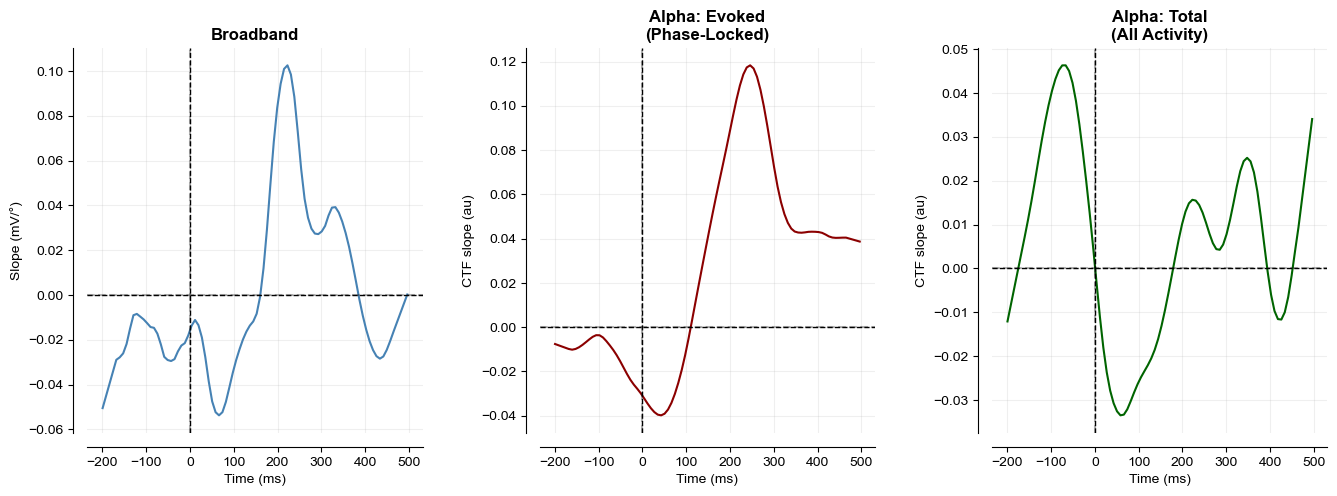

✓ Three-way comparison complete

Key observations:
  • Are evoked and total similar or different?
  • Stronger/weaker selectivity in total power?
  • Transient or sustained mechanism?


In [30]:
# 3-panel comparison: Broadband vs Alpha Evoked vs Alpha Total
plt.close('all')

fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1], wspace=0.35)

# Panel 1: Broadband
ax1 = fig.add_subplot(gs[0, 0])
plt.sca(ax1)
plot_ctf_timecourse(ctf_params, cnds=['localizer'], colors=['steelblue'],
                    output='voltage_slopes', smooth=True, show_legend=False, stats=None)
ax1.set_title('Broadband', fontsize=12, fontweight='bold')
ax1.set_ylabel('Slope (mV/°)')
ax1.axhline(0, color='k', linestyle='--', alpha=0.3)
ax1.axvline(0, color='k', linestyle='--', alpha=0.3)
ax1.grid(True, alpha=0.2)

# Panel 2: Alpha Evoked
ax2 = fig.add_subplot(gs[0, 1])
plt.sca(ax2)
plot_ctf_timecourse(ctf_params_alpha, cnds=['localizer'], colors=['darkred'],
                    output='E_slopes', smooth=True, show_legend=False, stats=None)
ax2.set_title('Alpha: Evoked\n(Phase-Locked)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Time (ms)')
ax2.axhline(0, color='k', linestyle='--', alpha=0.3)
ax2.axvline(0, color='k', linestyle='--', alpha=0.3)
ax2.grid(True, alpha=0.2)

# Panel 3: Alpha Total
ax3 = fig.add_subplot(gs[0, 2])
plt.sca(ax3)
plot_ctf_timecourse(ctf_params_alpha, cnds=['localizer'], colors=['darkgreen'],
                    output='T_slopes', smooth=True, show_legend=False, stats=None)
ax3.set_title('Alpha: Total\n(All Activity)', fontsize=12, fontweight='bold')
ax3.axhline(0, color='k', linestyle='--', alpha=0.3)
ax3.axvline(0, color='k', linestyle='--', alpha=0.3)
ax3.grid(True, alpha=0.2)

plt.tight_layout()
display(fig)
plt.close('all')

print("✓ Three-way comparison complete")
print("\nKey observations:")
print("  • Are evoked and total similar or different?")
print("  • Stronger/weaker selectivity in total power?")
print("  • Transient or sustained mechanism?")

## Cross-Task Generalization

In [31]:
# Compute generalization: localizer → main task
ctfs_cross, ctf_params_cross, _ = ctf_localizer.spatial_ctf(
    pos_labels='all', cnds=dict(block_type=[['localizer'], ['main']]),
    window_oi=(-0.2, 0.5), freqs='broadband'
)

print("✓ Generalization computed")

Creating bassiset with sin_power  7
Setting up low-pass filter at 8 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 8.00 Hz
- Upper transition bandwidth: 2.00 Hz (-6 dB cutoff frequency: 9.00 Hz)
- Filter length: 845 samples (1.650 s)

Frequency 1 out of 1
Applying baseline correction (mode: mean)
Running ctf for localizer_main condition
get ctf tuning params
✓ Generalization computed


Times converted from seconds to milliseconds


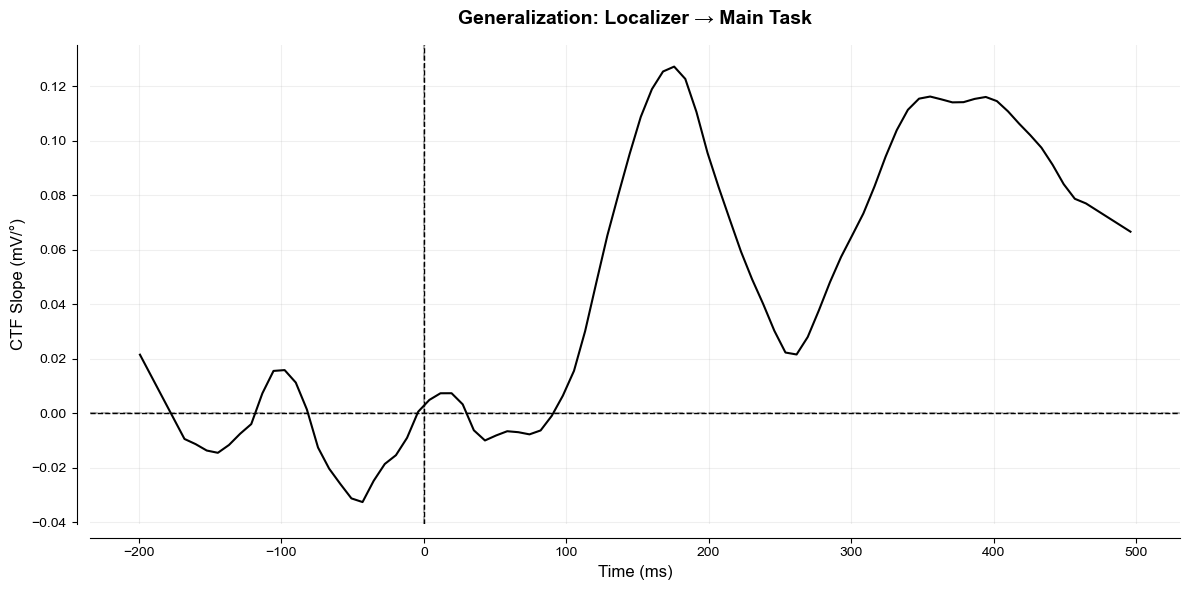

✓ Generalization visualization complete


In [32]:
# Visualize generalization
fig = plt.figure(figsize=(12, 6))
plt.sca(fig.gca())

plot_ctf_timecourse(ctf_params_cross, cnds=['localizer_main'], colors=['black'],
                    output='voltage_slopes', smooth=True, show_legend=False, stats=None)

plt.title('Generalization: Localizer → Main Task', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Time (ms)', fontsize=12)
plt.ylabel('CTF Slope (mV/°)', fontsize=12)
plt.axhline(0, color='k', linestyle='--', alpha=0.3)
plt.axvline(0, color='k', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.2)

plt.tight_layout()
display(fig)
plt.close('all')

print("✓ Generalization visualization complete")

## Optional: Multi-Frequency Analysis (2–30 Hz)

In [ ]:
# Initialize multi-frequency CTF
ctf_tfr = CTF(
    sj=sj, epochs=epochs, df=df, to_decode='img_loc',
    nr_bins=8, nr_chans=8, elec_oi='all', filter=8,
    avg_ch=True, baseline=(-0.2, 0), downsample=128,
    min_freq=2, max_freq=30, num_frex=10, freq_scaling='linear'
)

_, ctf_params_tfr, _ = ctf_tfr.spatial_ctf(
    pos_labels='all', cnds=dict(block_type=['localizer']),
    window_oi=(-0.2, 0.5), freqs='main_param'
)

print("✓ Multi-frequency CTF computed")

In [ ]:
# Visualize frequency × time
fig = plt.figure(figsize=(14, 6))
plt.sca(fig.gca())

plot_ctf_timecourse(ctf_params_tfr, cnds=['localizer'], colors=['black'],
                    output='E_slopes', timecourse='2d_tfr', smooth=True)

plt.title('Spatial Tuning Across Frequencies (2–30 Hz)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Time (ms)', fontsize=11)
plt.ylabel('Frequency (Hz)', fontsize=11)

plt.tight_layout()
display(fig)
plt.close('all')

print("✓ Multi-frequency visualization complete")

## Summary

### Localizer Spatial Tuning
- **Broadband**: Peak selectivity at [INSERT LATENCY] ms
- **Alpha evoked**: [INSERT VALUE]
- **Alpha total**: [INSERT VALUE]
- **Mechanism**: [TRANSIENT / SUSTAINED / BOTH]

### Cross-Task Generalization
- **Strength**: [STRONG / MODERATE / WEAK]
- **Interpretation**: [STABLE / TASK-SPECIFIC]

### Key Finding
Spatial attention operates through:
1. Multivariate EEG patterns (broadband)
2. Oscillatory modulation (alpha)
3. Stable representations that transfer across tasks